## 将突变体变化值分类

In [ ]:
# 加载数据集
kineticsType = "kkm"

import torch
rawData = torch.load(f"../../KCAT/Data/all_kinetics_data.pt")
from collections import defaultdict
wildTypeValue = defaultdict(float)
# 加载全部数据集
trainPair = torch.load(f"../Data/{kineticsType.upper()}TrainPairInfo")
testPair = torch.load(f"../Data/{kineticsType.upper()}TestPairInfo")
for item in trainPair+testPair:
    if len(item[3]) < 2:
        dataItem = rawData['kinetics_data'][kineticsType][item[3][0]]
        if dataItem['type'] == 'wild':
            k = f"{dataItem['ec']}#{dataItem['organism']}#{dataItem['substrate']}#{dataItem['smiles']}"
            wildTypeValue[k] = dataItem['value']
wildTypeValue = dict(wildTypeValue)
# 从测试集找到突变体
foldInfo = []
pairInfo = []
for item in testPair:
    if len(item[3]) < 2:
        dataItem = rawData['kinetics_data'][kineticsType][item[3][0]]
        if dataItem['type'] == 'mutant':
            k = f"{dataItem['ec']}#{dataItem['organism']}#{dataItem['substrate']}#{dataItem['smiles']}"
            wildValue = wildTypeValue.get(k)
            if wildValue is not None:
                fold = float(dataItem['value']) / float(wildValue)
                pairInfo.append(item[:-1])
                foldInfo.append(fold)
import numpy as np
foldInfo = np.array(foldInfo)
pairInfo = np.array(pairInfo)
# 预测
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_base import predict
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-1/model/pre-train-trainR2:0.9161-devR2=0.6674-RMSE=0.8867-MAE=0.5639-epoch=100",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-1/model/pre-train-trainR2:0.8980-devR2=0.6307-RMSE=0.7941-MAE=0.5537-epoch=100",
    'kkm':"../../KKM/TrainInfo/models/initialTrain-MACCSKeys/ECFPKKmPredictor-trainR2:0.8893-devR2=0.6136-RMSE=1.1116-MAE=0.7944-epoch=100"
}
real, pre = predict(
                    kineticsType.upper(),
                    modelPath[kineticsType],
                    pairInfo,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True if kineticsType != 'kkm' else False,
                    torch.device("cuda:0"),
                    "MACCSKeys"
                   )

In [ ]:
# 绘图
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
real = np.array(real)
pre = np.array(pre)
err = np.abs(real - pre)
plt.figure(figsize=(5,5))
rc('font',**{'family':'Times New Roman'})
plt.rcParams['pdf.fonttype'] = 42
plt.tick_params(direction='in')
plt.tick_params(which='major',length=1.5)
plt.tick_params(which='major',width=0.4)

boxData = [err[(foldInfo>10)|(foldInfo<=0.1)], err[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], err[(foldInfo<=2)|(foldInfo>0.5)]]
labels = ['Extremely Change', 'High Change', 'Normal Change']

boxplot = plt.boxplot(boxData, 
            labels=labels, 
            showfliers=False,
            showmeans=True,
            patch_artist=True,
            medianprops={'color': 'orange'},
            whiskerprops={'linestyle': '--', 'color': 'gray'},
            capprops={'color': 'gray'},
#             flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
           )
colors = ['#99CCCC', '#FFCC99', '#FFCCCC']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)
    
plt.xticks(fontsize=11)

plt.text(1.3, 8.5, f'Extremely Change:  $R^{2}$= {metric(pre[(foldInfo>10)|(foldInfo<=0.1)], real[(foldInfo>10)|(foldInfo<=0.1)], True)["r2"]:.3f}', fontweight ="normal", fontsize=11)
print(metric(pre[(foldInfo>10)|(foldInfo<=0.1)], real[(foldInfo>10)|(foldInfo<=0.1)], True))
plt.text(1.3, 8.0, f'High Change:  $R^{2}$= {metric(pre[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], real[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], True)["r2"]:.3f}', fontweight ="normal", fontsize=11)
print(metric(pre[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], real[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], True))
plt.text(1.3, 7.5, f'Normal Change:  $R^{2}$= {metric(pre[(foldInfo<=2)|(foldInfo>0.5)], real[(foldInfo<=2)|(foldInfo>0.5)], True)["r2"]:.3f}', fontweight ="normal", fontsize=11)
print(metric(pre[(foldInfo<=2)|(foldInfo>0.5)], real[(foldInfo<=2)|(foldInfo>0.5)], True))

ax = plt.gca()
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)

plt.ylabel("Experimental Log10-scaled Absolute Error", fontdict={'weight': 'normal', 'fontname': 'Times New Roman', 'size': 12})
plt.savefig(f"../Fig/Fig4-MACCSKeys-{kineticsType}-mutantFold.png", dpi=600, bbox_inches='tight')

## 迭代后的模型测试

In [1]:
# 加载数据集
kineticsType = "kcat"

import torch
rawData = torch.load(f"../../KCAT/Data/all_kinetics_data.pt")
from collections import defaultdict
wildTypeValue = defaultdict(float)
# 加载全部数据集
trainPair = torch.load(f"../Data/{kineticsType.upper()}TrainPairInfo")
testPair = torch.load(f"../Data/{kineticsType.upper()}TestPairInfo")
for item in trainPair+testPair:
    if len(item[3]) < 2:
        dataItem = rawData['kinetics_data'][kineticsType][item[3][0]]
        if dataItem['type'] == 'wild':
            k = f"{dataItem['ec']}#{dataItem['organism']}#{dataItem['substrate']}#{dataItem['smiles']}"
            wildTypeValue[k] = dataItem['value']
wildTypeValue = dict(wildTypeValue)
# 从测试集找到突变体
foldInfo = []
pairInfo = []
for item in testPair:
    if len(item[3]) < 2:
        dataItem = rawData['kinetics_data'][kineticsType][item[3][0]]
        if dataItem['type'] == 'mutant':
            k = f"{dataItem['ec']}#{dataItem['organism']}#{dataItem['substrate']}#{dataItem['smiles']}"
            wildValue = wildTypeValue.get(k)
            if wildValue is not None:
                fold = float(dataItem['value']) / float(wildValue)
                pairInfo.append(item[:-1])
                foldInfo.append(fold)
import numpy as np
foldInfo = np.array(foldInfo)
pairInfo = np.array(pairInfo)
# 预测
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_iter import predict
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9408-devR2=0.7459-RMSE=0.7751-MAE=0.4787-epoch=3",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9303-devR2=0.7163-RMSE=0.6960-MAE=0.4802-epoch=3",
    'kkm':"../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9188-devR2=0.8245-RMSE=0.7592-MAE=0.5030-epoch=4"
}
real, pre = predict(
                    kineticsType.upper(),
                    modelPath[kineticsType],
                    pairInfo,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True,
                    torch.device("cuda:0"),
                    "MACCSKeys"
                   )

log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 11/11 [00:04<00:00,  2.45it/s]


{'MAE': 0.5512097114982197, 'rmse': 0.899073539767412, 'r2': 0.663102685114757, 'r': 0.8381969236543767, 'p_value': 9.799036901459387e-105, 'samples': 392}
{'MAE': 0.32497192620134274, 'rmse': 0.5195810185852549, 'r2': 0.8542188039588268, 'r': 0.9243602698974378, 'p_value': 3.8450542851751305e-153, 'samples': 363}
{'MAE': 0.3793020902979554, 'rmse': 0.6597796420135968, 'r2': 0.8245166875613624, 'r': 0.9088414515118544, 'p_value': 0.0, 'samples': 1092}


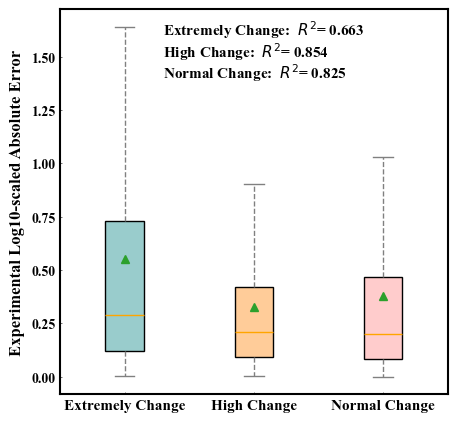

In [11]:
# 绘图
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
real = np.array(real)
pre = np.array(pre)
err = np.abs(real - pre)
plt.figure(figsize=(5,5))
rc('font',**{'family':'Times New Roman'})
plt.rcParams['pdf.fonttype'] = 42
plt.tick_params(direction='in')
plt.tick_params(which='major',length=1.5)
plt.tick_params(which='major',width=0.4)

boxData = [err[(foldInfo>10)|(foldInfo<=0.1)], err[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], err[(foldInfo<=2)|(foldInfo>0.5)]]
# labels = ['Extremely Change', 'High Change', 'Normal Change']
# plt.rcParams['ytick.labelweight'] = 'bold'
boxplot = plt.boxplot(boxData, 
#             labels=labels, 
            showfliers=False,
            showmeans=True,
            patch_artist=True,
            medianprops={'color': 'orange'},
            whiskerprops={'linestyle': '--', 'color': 'gray'},
            capprops={'color': 'gray'},
#             flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
           )
# plt.rc('font', weight='bold')

ax = plt.gca() 
ax.set_xticklabels(['Extremely Change', 'High Change', 'Normal Change'], fontweight='bold')
labels = ax.get_yticklabels()
for label in labels:
    label.set_fontweight('bold')
colors = ['#99CCCC', '#FFCC99', '#FFCCCC']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)
    
plt.xticks(fontsize=11)

x = 0
y = 0
step = 0
if kineticsType == 'kkm':
    x = 1.5
    y = 1.9
    step = 0.1
elif kineticsType == 'kcat':
    x = 1.3
    y = 1.6
    step = 0.1
elif kineticsType == 'km':
    x = 1.5
    y = 2.1
    step = 0.1

plt.text(x, y, f'Extremely Change:  $R^{2}$= {metric(pre[(foldInfo>10)|(foldInfo<=0.1)], real[(foldInfo>10)|(foldInfo<=0.1)], True)["r2"]:.3f}', fontweight ="bold", fontsize=11)
print(metric(pre[(foldInfo>10)|(foldInfo<=0.1)], real[(foldInfo>10)|(foldInfo<=0.1)], True))
plt.text(x, y-step, f'High Change:  $R^{2}$= {metric(pre[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], real[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], True)["r2"]:.3f}', fontweight ="bold", fontsize=11)
print(metric(pre[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], real[((foldInfo>2)&(foldInfo<=10))|((foldInfo>0.1)&(foldInfo<=0.5))], True))
plt.text(x, y-2*step, f'Normal Change:  $R^{2}$= {metric(pre[(foldInfo<=2)|(foldInfo>0.5)], real[(foldInfo<=2)|(foldInfo>0.5)], True)["r2"]:.3f}', fontweight ="bold", fontsize=11)
print(metric(pre[(foldInfo<=2)|(foldInfo>0.5)], real[(foldInfo<=2)|(foldInfo>0.5)], True))

ax = plt.gca()
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.xaxis.labelpad = 30
plt.ylabel("Experimental Log10-scaled Absolute Error", fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12})
plt.savefig(f"../Fig/Fig4-iter8-MACCSKeys-{kineticsType}-mutantFold.png", dpi=600, bbox_inches='tight')

In [21]:
print(foldInfo[(foldInfo>10)].mean())
print(foldInfo[(foldInfo<=0.1)].mean())

print(foldInfo[((foldInfo>2)&(foldInfo<=10))].mean())
print(foldInfo[((foldInfo>0.1)&(foldInfo<=0.5))].mean())

print(foldInfo[(foldInfo>1)&(foldInfo<=2)].mean())
print(foldInfo[(foldInfo>0.5)&(foldInfo<=1)].mean())

8284.168580105676
0.025675674315678878
4.441582176215381
0.2853333544169849
1.3345095103353442
0.7664728561623672
